In [1]:
# Section 0 - Settings
from pathlib import Path

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml

pd.set_option("display.max_columns", None)
plt.rcParams.update({"figure.dpi": 120})

csv_path = "/project/def-nahee/kbas/Graphnet-Applications/Results/340StringMC/102_string_emax1e6/inference/second_category/exp002/inference/inference_predictions.csv"
pipeline_config_path = "/project/def-nahee/kbas/Graphnet-Applications/Results/340StringMC/102_string_emax1e6/inference/second_category/exp002/inference/pipeline_config.yml"
output_dir = Path("/project/def-nahee/kbas/Graphnet-Applications/Results/340StringMC/102_string_emax1e6/inference/second_category/exp002/inference")

df = pd.read_csv(csv_path)
if "true_log10_energy" not in df.columns and "true_energy" in df.columns:
    df["true_log10_energy"] = np.log10(df["true_energy"])
with open(pipeline_config_path) as f:
    pipeline_cfg = yaml.safe_load(f)
with open(pipeline_cfg["classification"]["config"]) as f:
    classification_cfg = yaml.safe_load(f)

task_cfg = classification_cfg["task"]
class_labels = [int(label) for label in task_cfg["labels"]]
raw_class_names = task_cfg.get("class_names", {}) or {}
class_names = {int(k): str(v) for k, v in raw_class_names.items()}

true_class_col = "true_classification_class"
pred_class_col = "predicted_route_class"
analysis_group_col = "_pid_interaction_group"

def class_label(value):
    if pd.isna(value):
        return "missing"
    value = int(value)
    return class_names.get(value, f"class {value}")

def particle_label(pid):
    if pd.isna(pid):
        return "pid missing"
    pid_int = int(pid)
    names = {12: "electron", 14: "muon", 16: "tau"}
    return names.get(abs(pid_int), f"pid {abs(pid_int)}")

def interaction_label(value):
    if pd.isna(value):
        return "interaction missing"
    value_int = int(value)
    names = {1: "CC", 2: "NC"}
    return names.get(value_int, f"interaction {value_int}")

def pid_interaction_group(pid, interaction_type):
    interaction = interaction_label(interaction_type)
    if interaction == "NC":
        return "NC"
    return f"{particle_label(pid)} {interaction}"

if {"pid", "interaction_type"}.issubset(df.columns):
    df[analysis_group_col] = [pid_interaction_group(pid, interaction_type) for pid, interaction_type in zip(df["pid"], df["interaction_type"])]

def group_label(key):
    return str(key)

def sigma68(values):
    values = pd.Series(values).replace([np.inf, -np.inf], np.nan).dropna()
    if len(values) == 0:
        return np.nan
    return 0.5 * (np.percentile(values, 84) - np.percentile(values, 16))

def binned_sigma(frame, x_col, residual_col, bins):
    work = frame[[x_col, residual_col]].replace([np.inf, -np.inf], np.nan).dropna().copy()
    if work.empty:
        return pd.DataFrame(columns=["bin_center", "sigma68", "count"])
    work["bin"] = pd.cut(work[x_col], bins=bins, include_lowest=True)
    out = (
        work.groupby("bin", observed=True)[residual_col]
        .agg(count="count", sigma68=sigma68)
        .reset_index()
    )
    out["bin_center"] = out["bin"].map(lambda item: item.mid).astype(float)
    return out

def subplot_grid(n_items, width=5.2, height=4.2):
    ncols = min(2, max(1, n_items))
    nrows = int(math.ceil(n_items / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(width * ncols, height * nrows), squeeze=False)
    return fig, axes.ravel()

def grouped_frames(frame):
    if analysis_group_col not in frame.columns:
        return []
    return list(frame.dropna(subset=[analysis_group_col]).groupby(analysis_group_col, sort=True))

df.head()


,event_key,event_no,RunID,SubrunID,EventID,SubEventID,position_x,position_y,position_z,pid,interaction_type,totalEnergy,zenith,azimuth,finalStateX,finalStateY,finalType1,finalType2,initialType,totalColumnDepth,impactParameter,fully_contained,starting_track,stopping_track,through_going,missed_track,true_classification_class,predicted_route_class,p_class_0,p_class_1,p_class_2,true_energy,true_log10_energy,pred_energy,pred_log10_energy,true_zenith_radian,pred_zenith_radian,true_zenith_degree,pred_zenith_degree,residual_zenith_degree,zenith_kappa,true_azimuth_radian,pred_azimuth_radian,true_azimuth_degree,pred_azimuth_degree,residual_azimuth_degree,azimuth_kappa,pred_azimuth_degree_signed,_pid_interaction_group
0,76:3:4294967295:183:0,76.0,3.0,4.294967e+09,183.0,0.0,-1061.060256,-311.323873,785.597908,-14.0,1.0,281.395344,1.276237,3.293976,0.242475,0.020829,-13.0,-2.000001e+09,-14.0,3.568156e+05,457.697731,0.0,0.0,1.0,0.0,0.0,2.0,1,0.305571,5.031925e-01,0.191236,281.395344,2.449317,254.35489,2.405440,1.276237,1.139038,73.12297,65.262090,-7.860879,3.832124,3.293976,4.510289,188.730930,258.420500,69.689580,0.119006,-101.57951,muon CC
1,370:18:4294967295:21:0,370.0,18.0,4.294967e+09,21.0,0.0,-403.225009,-626.585901,659.881227,14.0,1.0,992.633377,0.820611,3.455635,0.516496,0.321261,13.0,-2.000001e+09,14.0,4.498558e+05,479.770221,0.0,0.0,0.0,1.0,0.0,2.0,2,0.076429,1.975253e-08,0.923571,992.633377,2.996789,362.61368,2.559444,0.820611,0.734851,47.01753,42.103840,-4.913689,96.281494,3.455635,3.561018,197.993290,204.031270,6.037969,48.092396,-155.96873,muon CC
2,545:32:4294967295:25:0,545.0,32.0,4.294967e+09,25.0,0.0,-243.777723,420.550082,54.883322,14.0,1.0,1385.304704,2.470683,1.468419,0.358114,0.733320,13.0,-2.000001e+09,14.0,7.028427e+05,445.707989,0.0,0.0,0.0,1.0,0.0,2.0,2,0.063996,1.307142e-10,0.936004,1385.304704,3.141545,1204.43690,3.080784,2.470684,2.387792,141.55974,136.810410,-4.749317,83.756420,1.468419,1.529784,84.134230,87.650185,3.515949,91.181530,87.65019,muon CC
3,588:25:4294967295:28:0,588.0,25.0,4.294967e+09,28.0,0.0,-721.418098,2012.839660,428.901788,14.0,1.0,3703.994825,1.592345,1.967033,0.205136,0.061413,13.0,-2.000001e+09,14.0,1.024291e+06,487.688409,0.0,0.0,0.0,1.0,0.0,2.0,2,0.055457,2.960146e-13,0.944543,3703.994825,3.568670,9444.59300,3.975183,1.592345,1.560752,91.23462,89.424500,-1.810116,102.524700,1.967033,1.918134,112.702670,109.901000,-2.801675,135.614880,109.90100,muon CC
4,907:45:4294967295:148:0,907.0,45.0,4.294967e+09,148.0,0.0,-408.267932,267.534376,-241.206723,-14.0,1.0,100652.361528,0.630212,1.088116,0.002083,0.588650,-13.0,-2.000001e+09,-14.0,4.815272e+05,518.250512,0.0,1.0,0.0,0.0,0.0,2.0,2,0.051759,1.594641e-02,0.932294,100652.361528,5.002824,321680.90000,5.507425,0.630212,0.400978,36.10850,22.974325,-13.134176,60.650063,1.088116,1.373331,62.344482,78.686060,16.341570,21.905407,78.68606,muon CC


## Section 1 - Confusion Matrix


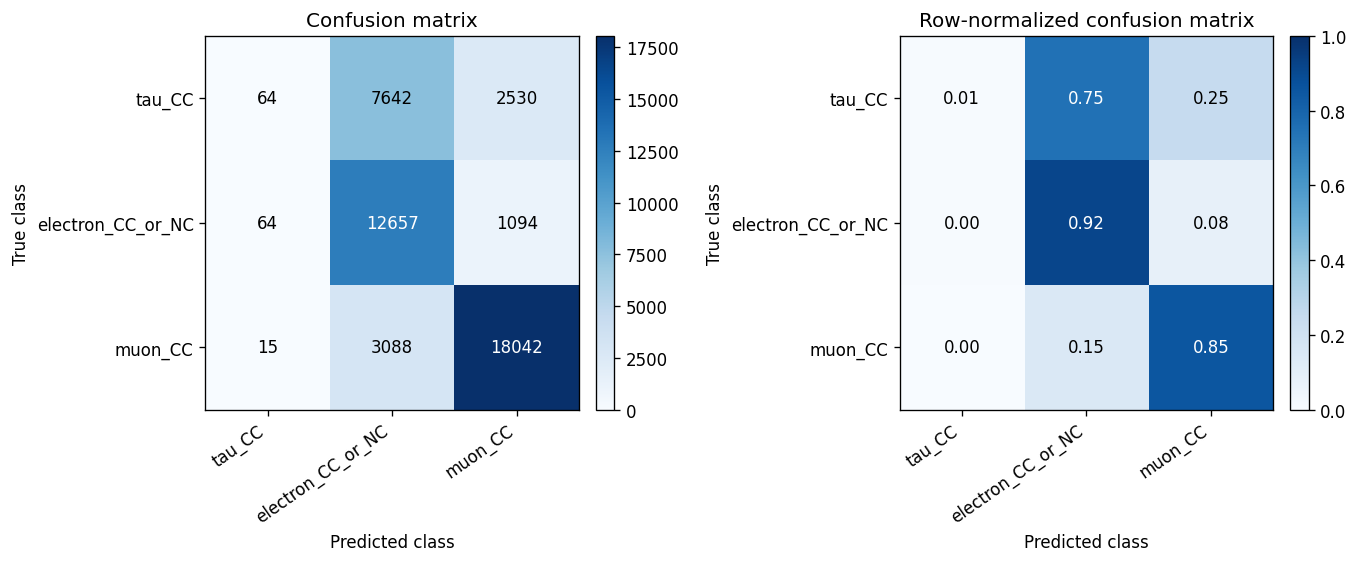

,tau_CC,electron_CC_or_NC,muon_CC
tau_CC,64,7642,2530
electron_CC_or_NC,64,12657,1094
muon_CC,15,3088,18042


In [2]:
def confusion_table(frame):
    work = frame[[true_class_col, pred_class_col]].dropna().copy()
    work[true_class_col] = work[true_class_col].astype(int)
    work[pred_class_col] = work[pred_class_col].astype(int)
    names = [class_label(label) for label in class_labels]
    table = pd.crosstab(work[true_class_col], work[pred_class_col]).reindex(
        index=class_labels, columns=class_labels, fill_value=0
    )
    table.index = names
    table.columns = names
    return table

cm_counts = confusion_table(df)
cm_norm = cm_counts.div(cm_counts.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.8))
for ax, table, title, fmt, vmax in [
    (axes[0], cm_counts, "Confusion matrix", "d", None),
    (axes[1], cm_norm, "Row-normalized confusion matrix", ".2f", 1),
]:
    im = ax.imshow(table.values, cmap="Blues", vmin=0, vmax=vmax)
    ax.set_xticks(np.arange(len(table.columns)), labels=table.columns, rotation=35, ha="right")
    ax.set_yticks(np.arange(len(table.index)), labels=table.index)
    ax.set_xlabel("Predicted class")
    ax.set_ylabel("True class")
    ax.set_title(title)
    threshold = np.nanmax(table.values) / 2 if table.values.size else 0
    for i in range(table.shape[0]):
        for j in range(table.shape[1]):
            value = table.iloc[i, j]
            ax.text(j, i, format(value, fmt), ha="center", va="center", color="white" if value > threshold else "black")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
plt.show()

cm_counts


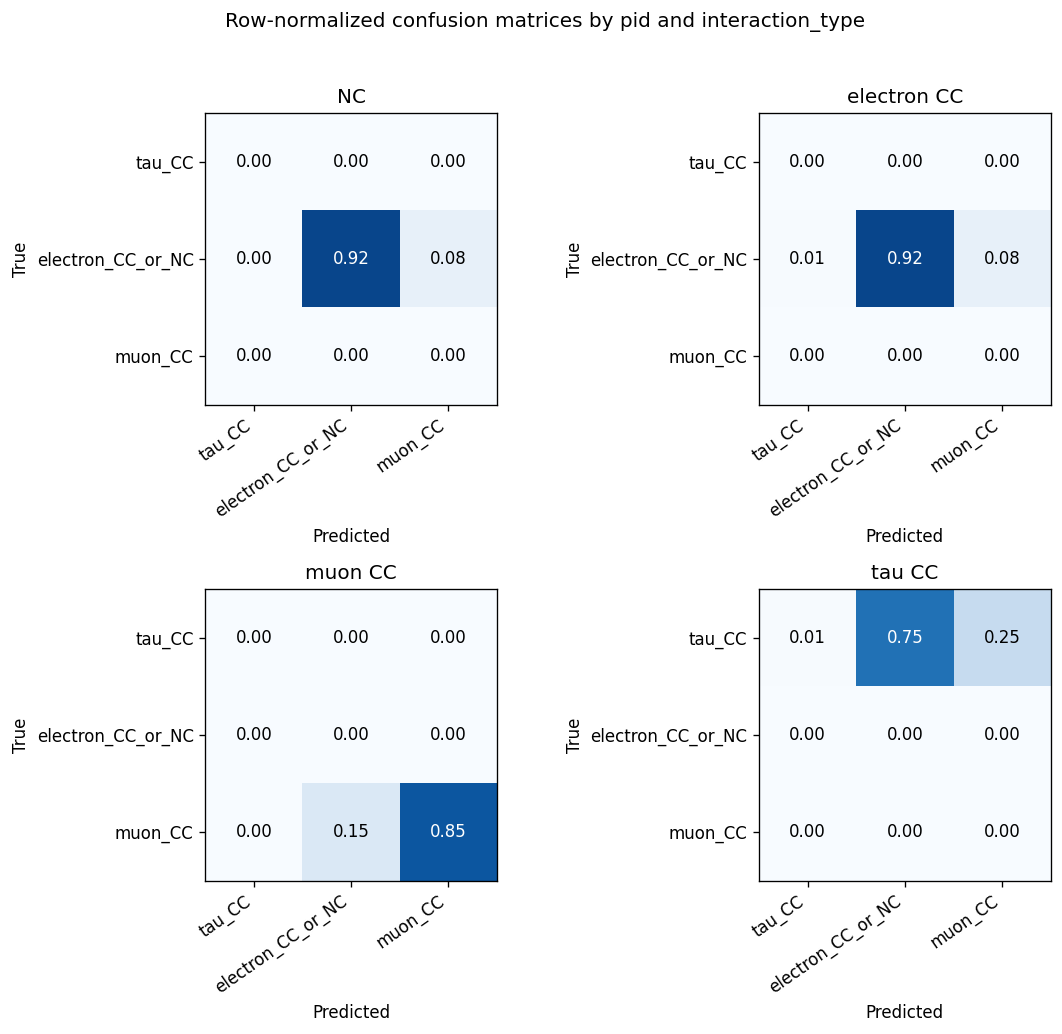

In [3]:
groups = grouped_frames(df)
if groups:
    fig, axes = subplot_grid(len(groups), width=4.8, height=4.2)
    for ax, (keys, group) in zip(axes, groups):
        table = confusion_table(group)
        norm = table.div(table.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)
        im = ax.imshow(norm.values, cmap="Blues", vmin=0, vmax=1)
        ax.set_xticks(np.arange(len(norm.columns)), labels=norm.columns, rotation=35, ha="right")
        ax.set_yticks(np.arange(len(norm.index)), labels=norm.index)
        ax.set_title(group_label(keys))
        ax.set_xlabel("Predicted")
        ax.set_ylabel("True")
        for i in range(norm.shape[0]):
            for j in range(norm.shape[1]):
                value = norm.iloc[i, j]
                ax.text(j, i, f"{value:.2f}", ha="center", va="center", color="white" if value > 0.5 else "black")
    for ax in axes[len(groups):]:
        ax.axis("off")
    fig.suptitle("Row-normalized confusion matrices by pid and interaction_type", y=1.02)
    fig.tight_layout()
    plt.show()
else:
    print("pid and interaction_type columns are not both available; grouped confusion matrices skipped.")


## Section 2 - Energy


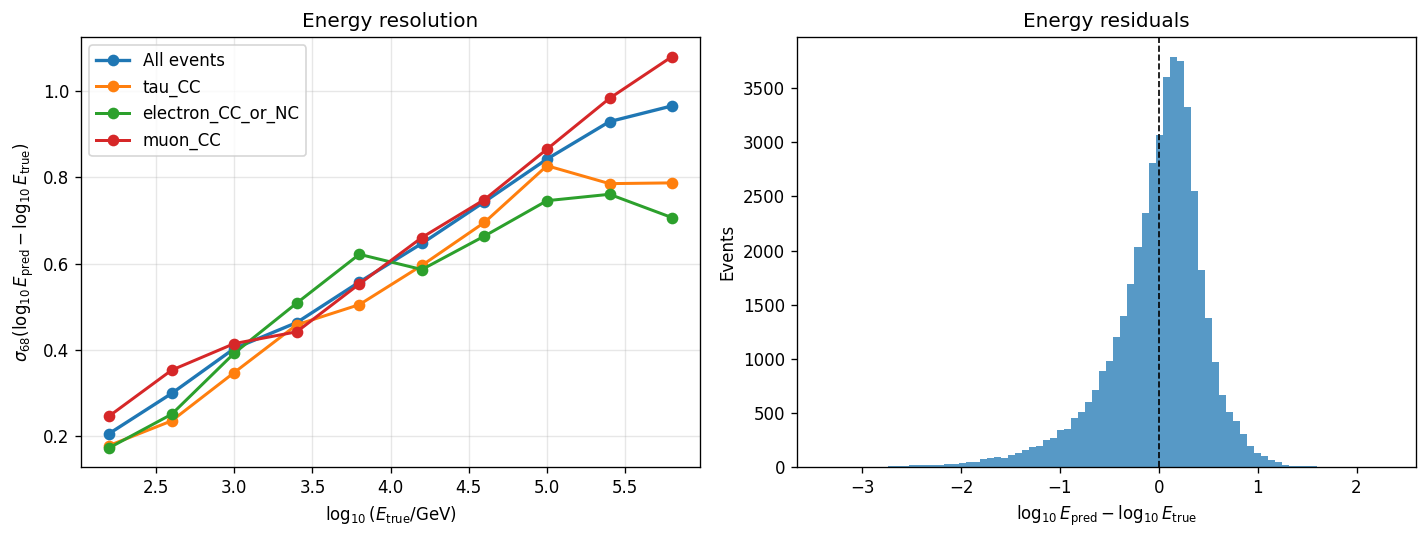

,count,median,mean,sigma68
0,45196,0.062178,-0.026396,0.408698


In [4]:
energy_needed = ["true_energy", "true_log10_energy", "pred_energy", "pred_log10_energy", true_class_col]
energy_df = df[[col for col in energy_needed if col in df.columns]].dropna().copy()
energy_df = energy_df[(energy_df["true_energy"] > 0) & (energy_df["pred_energy"] > 0)]
energy_df["energy_residual_log10"] = energy_df["pred_log10_energy"] - energy_df["true_log10_energy"]
bins = np.linspace(energy_df["true_log10_energy"].min(), energy_df["true_log10_energy"].max(), 11)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
overall = binned_sigma(energy_df, "true_log10_energy", "energy_residual_log10", bins)
axes[0].plot(overall["bin_center"], overall["sigma68"], marker="o", linewidth=2, label="All events")
for label, group in energy_df.groupby(true_class_col, sort=True):
    table = binned_sigma(group, "true_log10_energy", "energy_residual_log10", bins)
    axes[0].plot(table["bin_center"], table["sigma68"], marker="o", linewidth=1.8, label=class_label(label))
axes[0].set_xlabel(r"$\log_{10}(E_\mathrm{true}/\mathrm{GeV})$")
axes[0].set_ylabel(r"$\sigma_{68}(\log_{10}E_\mathrm{pred}-\log_{10}E_\mathrm{true})$")
axes[0].set_title("Energy resolution")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].hist(energy_df["energy_residual_log10"], bins=80, histtype="stepfilled", alpha=0.75)
axes[1].axvline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_xlabel(r"$\log_{10}E_\mathrm{pred}-\log_{10}E_\mathrm{true}$")
axes[1].set_ylabel("Events")
axes[1].set_title("Energy residuals")
fig.tight_layout()
plt.show()

pd.DataFrame({
    "count": [len(energy_df)],
    "median": [energy_df["energy_residual_log10"].median()],
    "mean": [energy_df["energy_residual_log10"].mean()],
    "sigma68": [sigma68(energy_df["energy_residual_log10"])],
})


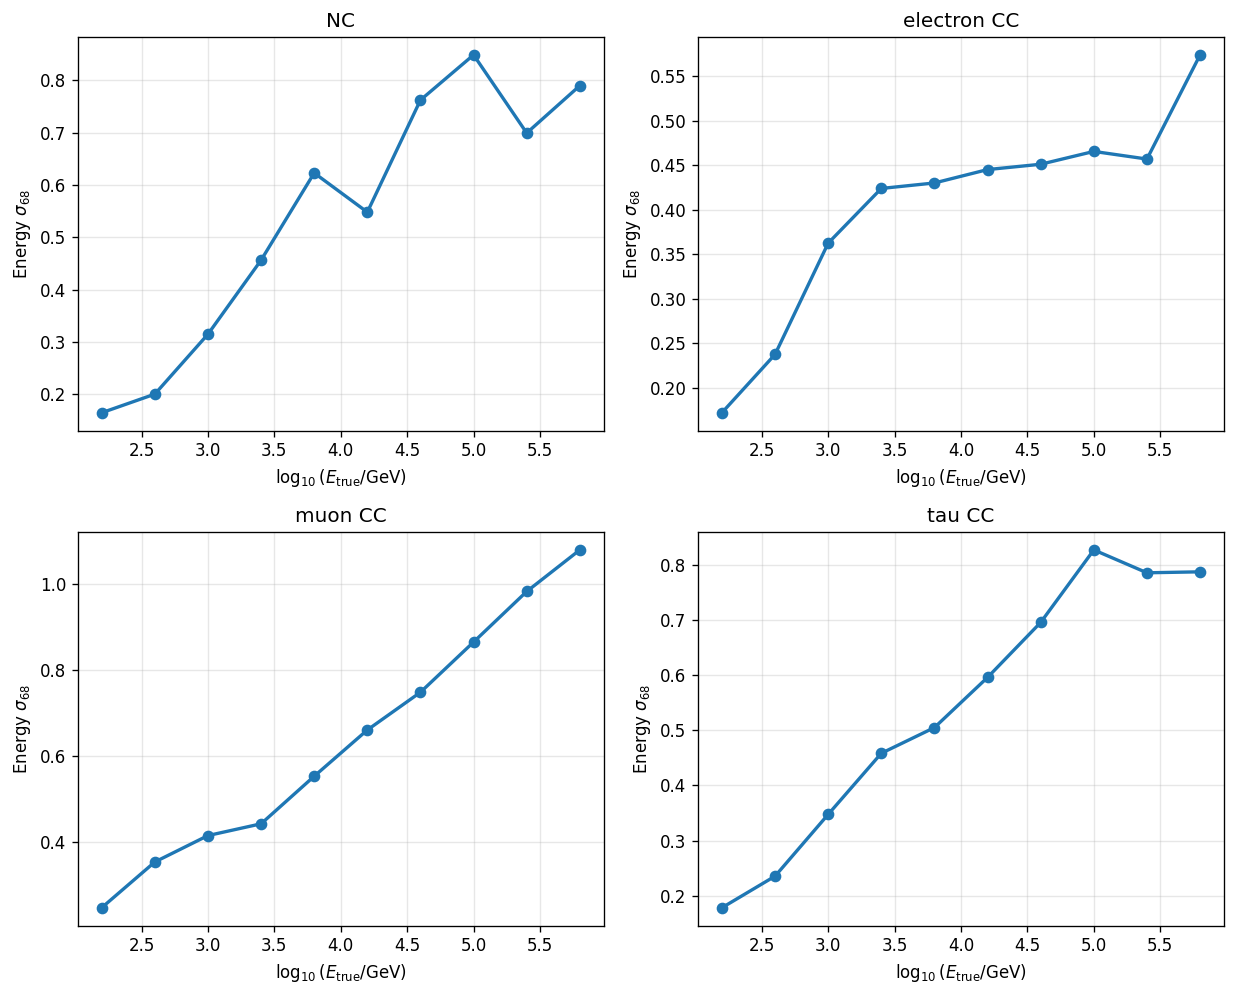

In [5]:
groups = grouped_frames(df)
if groups:
    fig, axes = subplot_grid(len(groups))
    for ax, (keys, group) in zip(axes, groups):
        sub = group.merge(energy_df[["energy_residual_log10"]], left_index=True, right_index=True, how="inner")
        if sub.empty:
            ax.axis("off")
            continue
        table = binned_sigma(sub, "true_log10_energy", "energy_residual_log10", bins)
        ax.plot(table["bin_center"], table["sigma68"], marker="o", linewidth=2)
        ax.set_title(group_label(keys))
        ax.set_xlabel(r"$\log_{10}(E_\mathrm{true}/\mathrm{GeV})$")
        ax.set_ylabel(r"Energy $\sigma_{68}$")
        ax.grid(True, alpha=0.3)
    for ax in axes[len(groups):]:
        ax.axis("off")
    fig.tight_layout()
    plt.show()


## Section 3 - Zenith


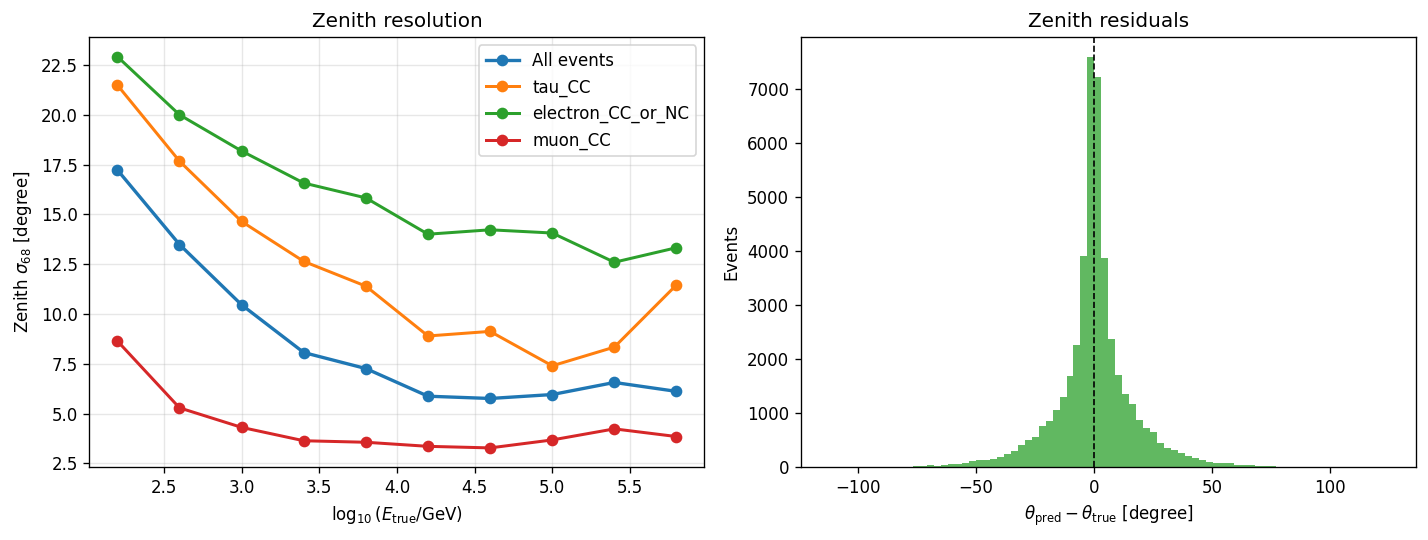

In [6]:
zenith_residual_col = "zenith_residual_zenith_degree" if "zenith_residual_zenith_degree" in df.columns else "residual_zenith_degree"
zenith_df = df[["true_log10_energy", zenith_residual_col, true_class_col]].dropna().copy()
zenith_df = zenith_df.rename(columns={zenith_residual_col: "zenith_residual_degree"})

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
overall = binned_sigma(zenith_df, "true_log10_energy", "zenith_residual_degree", bins)
axes[0].plot(overall["bin_center"], overall["sigma68"], marker="o", linewidth=2, label="All events")
for label, group in zenith_df.groupby(true_class_col, sort=True):
    table = binned_sigma(group, "true_log10_energy", "zenith_residual_degree", bins)
    axes[0].plot(table["bin_center"], table["sigma68"], marker="o", linewidth=1.8, label=class_label(label))
axes[0].set_xlabel(r"$\log_{10}(E_\mathrm{true}/\mathrm{GeV})$")
axes[0].set_ylabel(r"Zenith $\sigma_{68}$ [degree]")
axes[0].set_title("Zenith resolution")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].hist(zenith_df["zenith_residual_degree"], bins=80, histtype="stepfilled", alpha=0.75, color="tab:green")
axes[1].axvline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_xlabel(r"$\theta_\mathrm{pred}-\theta_\mathrm{true}$ [degree]")
axes[1].set_ylabel("Events")
axes[1].set_title("Zenith residuals")
fig.tight_layout()
plt.show()


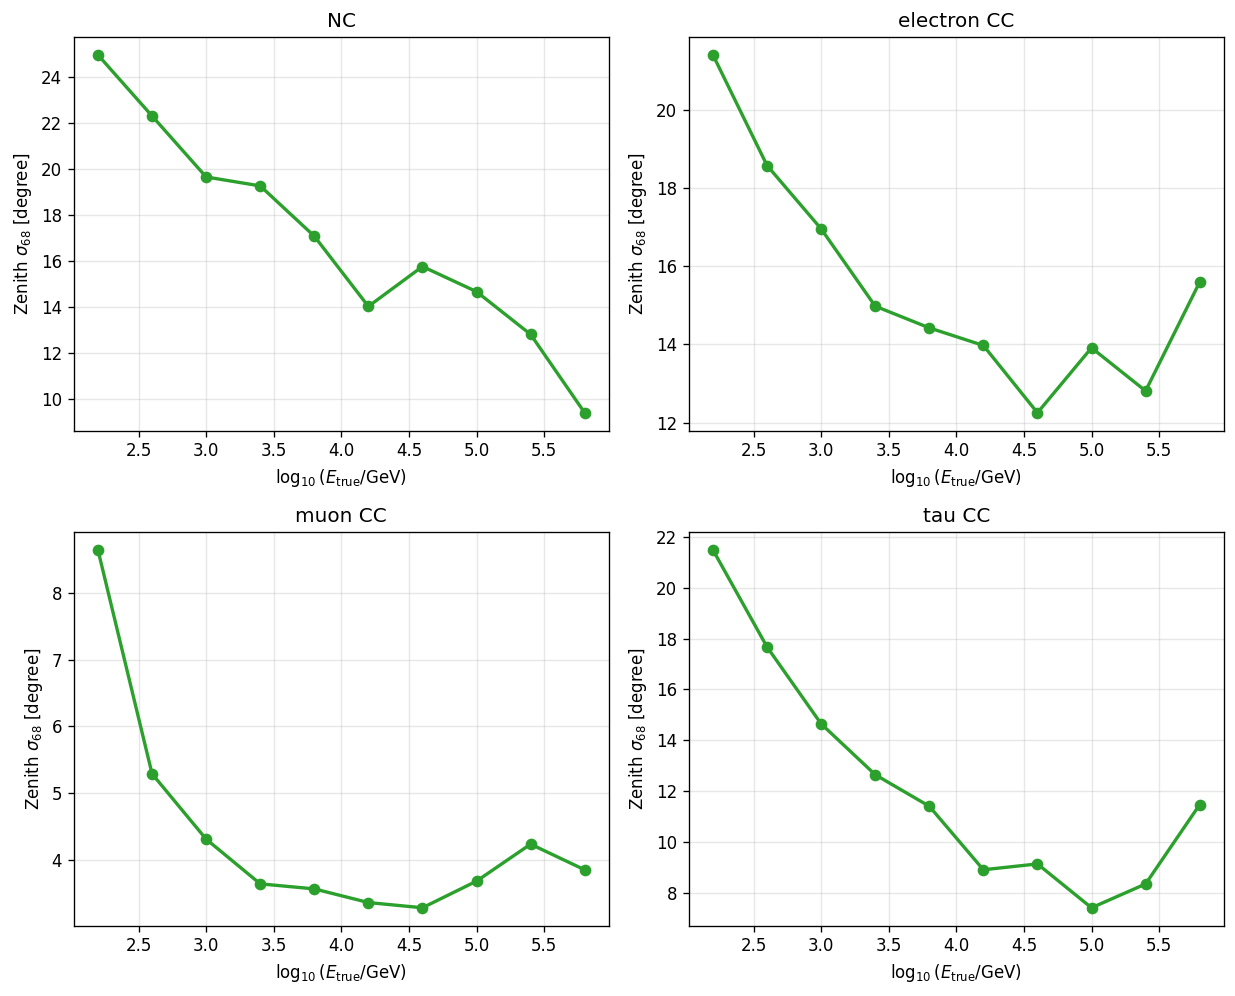

In [7]:
groups = grouped_frames(df)
if groups:
    fig, axes = subplot_grid(len(groups))
    for ax, (keys, group) in zip(axes, groups):
        sub = group.merge(zenith_df[["zenith_residual_degree"]], left_index=True, right_index=True, how="inner")
        table = binned_sigma(sub, "true_log10_energy", "zenith_residual_degree", bins)
        ax.plot(table["bin_center"], table["sigma68"], marker="o", linewidth=2, color="tab:green")
        ax.set_title(group_label(keys))
        ax.set_xlabel(r"$\log_{10}(E_\mathrm{true}/\mathrm{GeV})$")
        ax.set_ylabel(r"Zenith $\sigma_{68}$ [degree]")
        ax.grid(True, alpha=0.3)
    for ax in axes[len(groups):]:
        ax.axis("off")
    fig.tight_layout()
    plt.show()


## Section 4 - Azimuth


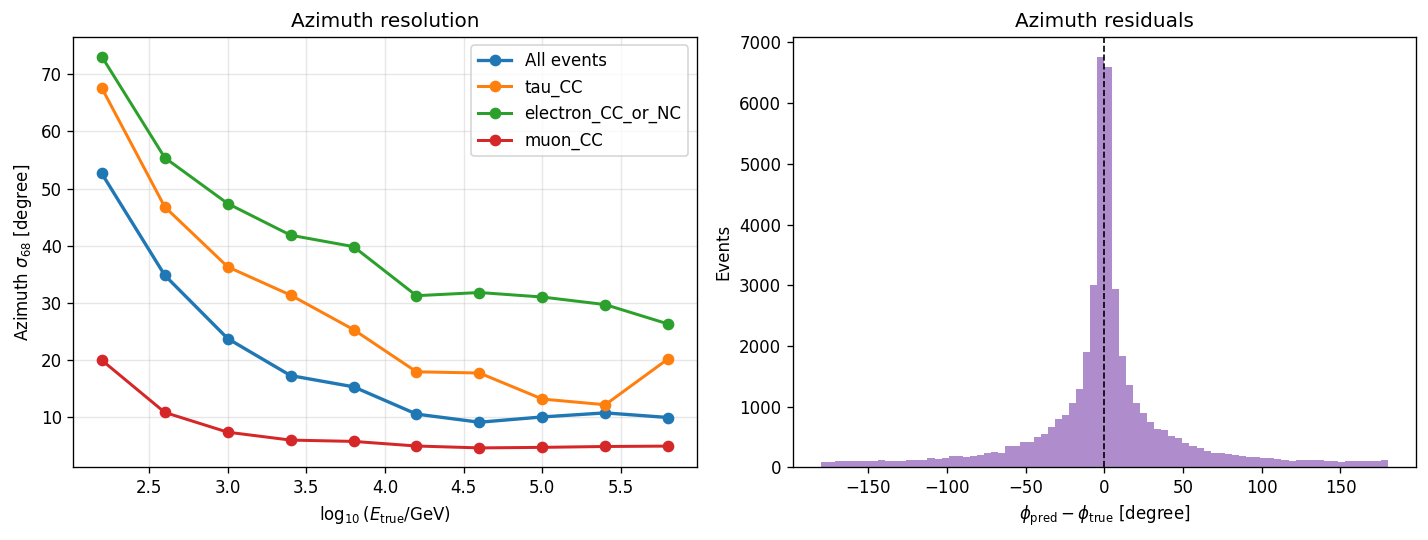

In [8]:
azimuth_residual_col = "azimuth_residual_azimuth_degree" if "azimuth_residual_azimuth_degree" in df.columns else "residual_azimuth_degree"
azimuth_df = df[["true_log10_energy", azimuth_residual_col, true_class_col]].dropna().copy()
azimuth_df = azimuth_df.rename(columns={azimuth_residual_col: "azimuth_residual_degree"})

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
overall = binned_sigma(azimuth_df, "true_log10_energy", "azimuth_residual_degree", bins)
axes[0].plot(overall["bin_center"], overall["sigma68"], marker="o", linewidth=2, label="All events")
for label, group in azimuth_df.groupby(true_class_col, sort=True):
    table = binned_sigma(group, "true_log10_energy", "azimuth_residual_degree", bins)
    axes[0].plot(table["bin_center"], table["sigma68"], marker="o", linewidth=1.8, label=class_label(label))
axes[0].set_xlabel(r"$\log_{10}(E_\mathrm{true}/\mathrm{GeV})$")
axes[0].set_ylabel(r"Azimuth $\sigma_{68}$ [degree]")
axes[0].set_title("Azimuth resolution")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].hist(azimuth_df["azimuth_residual_degree"], bins=80, histtype="stepfilled", alpha=0.75, color="tab:purple")
axes[1].axvline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_xlabel(r"$\phi_\mathrm{pred}-\phi_\mathrm{true}$ [degree]")
axes[1].set_ylabel("Events")
axes[1].set_title("Azimuth residuals")
fig.tight_layout()
plt.show()


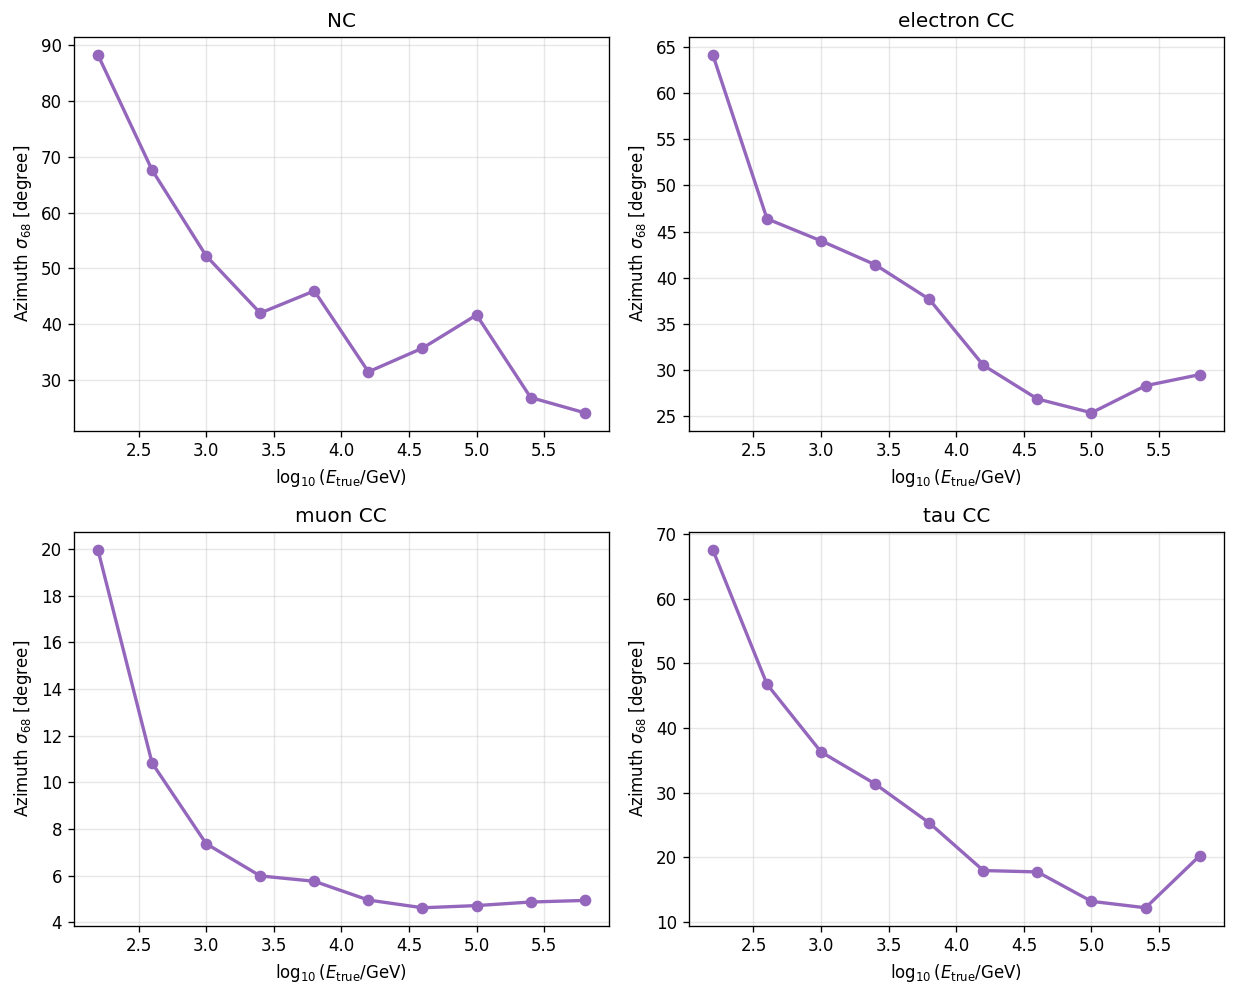

In [9]:
groups = grouped_frames(df)
if groups:
    fig, axes = subplot_grid(len(groups))
    for ax, (keys, group) in zip(axes, groups):
        sub = group.merge(azimuth_df[["azimuth_residual_degree"]], left_index=True, right_index=True, how="inner")
        table = binned_sigma(sub, "true_log10_energy", "azimuth_residual_degree", bins)
        ax.plot(table["bin_center"], table["sigma68"], marker="o", linewidth=2, color="tab:purple")
        ax.set_title(group_label(keys))
        ax.set_xlabel(r"$\log_{10}(E_\mathrm{true}/\mathrm{GeV})$")
        ax.set_ylabel(r"Azimuth $\sigma_{68}$ [degree]")
        ax.grid(True, alpha=0.3)
    for ax in axes[len(groups):]:
        ax.axis("off")
    fig.tight_layout()
    plt.show()


## Section 5 - Opening Angle


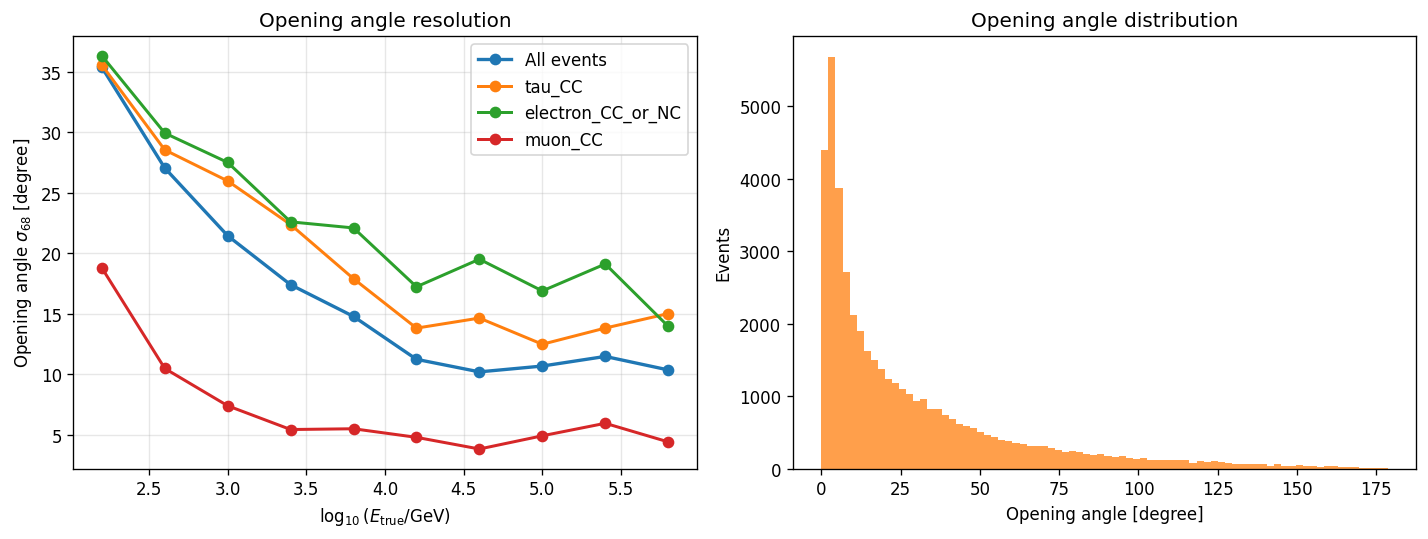

In [10]:
def opening_angle_deg(theta_true, phi_true, theta_pred, phi_pred):
    cos_delta = (
        np.sin(theta_true) * np.sin(theta_pred) * np.cos(phi_true - phi_pred)
        + np.cos(theta_true) * np.cos(theta_pred)
    )
    return np.degrees(np.arccos(np.clip(cos_delta, -1.0, 1.0)))

zen_true = "zenith_true_zenith_radian" if "zenith_true_zenith_radian" in df.columns else "true_zenith_radian"
zen_pred = "zenith_pred_zenith_radian" if "zenith_pred_zenith_radian" in df.columns else "pred_zenith_radian"
azi_true = "azimuth_true_azimuth_radian" if "azimuth_true_azimuth_radian" in df.columns else "true_azimuth_radian"
azi_pred = "azimuth_pred_azimuth_radian" if "azimuth_pred_azimuth_radian" in df.columns else "pred_azimuth_radian"

opening_cols = ["true_log10_energy", true_class_col, zen_true, zen_pred, azi_true, azi_pred]
opening_df = df[opening_cols].dropna().copy()
opening_df["opening_angle_degree"] = opening_angle_deg(opening_df[zen_true], opening_df[azi_true], opening_df[zen_pred], opening_df[azi_pred])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
overall = binned_sigma(opening_df, "true_log10_energy", "opening_angle_degree", bins)
axes[0].plot(overall["bin_center"], overall["sigma68"], marker="o", linewidth=2, label="All events")
for label, group in opening_df.groupby(true_class_col, sort=True):
    table = binned_sigma(group, "true_log10_energy", "opening_angle_degree", bins)
    axes[0].plot(table["bin_center"], table["sigma68"], marker="o", linewidth=1.8, label=class_label(label))
axes[0].set_xlabel(r"$\log_{10}(E_\mathrm{true}/\mathrm{GeV})$")
axes[0].set_ylabel(r"Opening angle $\sigma_{68}$ [degree]")
axes[0].set_title("Opening angle resolution")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].hist(opening_df["opening_angle_degree"], bins=80, histtype="stepfilled", alpha=0.75, color="tab:orange")
axes[1].set_xlabel("Opening angle [degree]")
axes[1].set_ylabel("Events")
axes[1].set_title("Opening angle distribution")
fig.tight_layout()
plt.show()


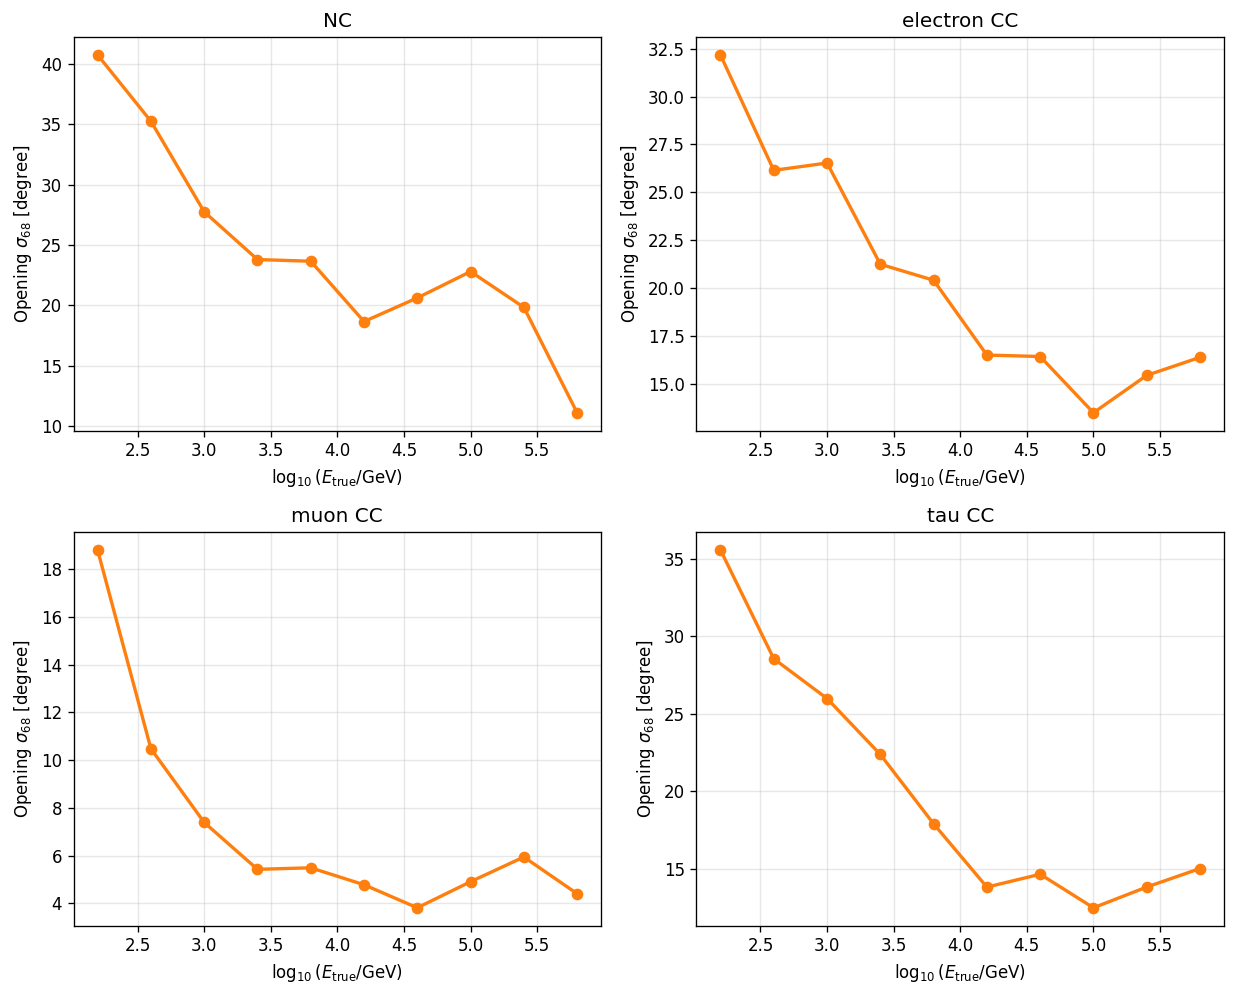

In [11]:
groups = grouped_frames(df)
if groups:
    fig, axes = subplot_grid(len(groups))
    for ax, (keys, group) in zip(axes, groups):
        sub = group.merge(opening_df[["opening_angle_degree"]], left_index=True, right_index=True, how="inner")
        table = binned_sigma(sub, "true_log10_energy", "opening_angle_degree", bins)
        ax.plot(table["bin_center"], table["sigma68"], marker="o", linewidth=2, color="tab:orange")
        ax.set_title(group_label(keys))
        ax.set_xlabel(r"$\log_{10}(E_\mathrm{true}/\mathrm{GeV})$")
        ax.set_ylabel(r"Opening $\sigma_{68}$ [degree]")
        ax.grid(True, alpha=0.3)
    for ax in axes[len(groups):]:
        ax.axis("off")
    fig.tight_layout()
    plt.show()
